In [15]:
# ============================================================
# Dropout Regularization — A/B Test (PyTorch)
# Variants: No Dropout | Standard | Alpha | MC Dropout
# ============================================================

# ─────────────────────────────────────────────
# CELL 1 — Imports
# ─────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
torch.manual_seed(42)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"PyTorch {torch.__version__} | Device: {DEVICE}")

# ─────────────────────────────────────────────
# CELL 2 — Dataset
# ─────────────────────────────────────────────
X, y = make_moons(n_samples=300, noise=0.3, random_state=42)
X = StandardScaler().fit_transform(X)
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

def to_t(a, dtype=torch.float32):
    return torch.tensor(a, dtype=dtype).to(DEVICE)

Xtr_t, ytr_t   = to_t(X_tr),  to_t(y_tr)
Xval_t, yval_t = to_t(X_val), to_t(y_val)

loader = DataLoader(TensorDataset(Xtr_t, ytr_t),
                    batch_size=32, shuffle=True)
print(f"Train: {Xtr_t.shape}  Val: {Xval_t.shape}")

PyTorch 2.10.0+cpu | Device: cpu
Train: torch.Size([210, 2])  Val: torch.Size([90, 2])


In [16]:
# ─────────────────────────────────────────────
# CELL 3 — Model definitions
#
# KEY PyTorch dropout concepts:
#
# nn.Dropout(p)
#   → standard dropout; zeros individual activations with prob p
#   → ONLY active when model.train() — disabled in model.eval()
#
# nn.AlphaDropout(p)
#   → designed for SELU activations
#   → preserves self-normalising property (mean≈0, var≈1)
#   → use with nn.SELU() + nn.init.kaiming_normal_ (lecun style)
#
# nn.Dropout2d(p)
#   → drops entire feature maps (channels) — for CNN inputs
#   → shown separately below
#
# MC Dropout:
#   → NOT a separate class — just call model.train() at inference time
#   → run N forward passes → mean + std = prediction + uncertainty
# ─────────────────────────────────────────────
RATE = 0.4

class NoDropoutMLP(nn.Module):
    """Baseline — no regularisation; will overfit easily."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 1), nn.Sigmoid(),
        )
    def forward(self, x): return self.net(x).squeeze(-1)


class StandardDropoutMLP(nn.Module):
    """Standard nn.Dropout after each ReLU layer."""
    def __init__(self, rate=RATE):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 256),   nn.ReLU(),  nn.Dropout(rate),  # ← Dropout here
            nn.Linear(256, 256), nn.ReLU(),  nn.Dropout(rate),
            nn.Linear(256, 256), nn.ReLU(),  nn.Dropout(rate),
            nn.Linear(256, 256), nn.ReLU(),  nn.Dropout(rate),
            nn.Linear(256, 1),   nn.Sigmoid(),
        )
    def forward(self, x): return self.net(x).squeeze(-1)


class AlphaDropoutMLP(nn.Module):
    """AlphaDropout + SELU — self-normalising network."""
    def __init__(self, rate=RATE):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 256),   nn.SELU(), nn.AlphaDropout(rate),  # ← AlphaDropout
            nn.Linear(256, 256), nn.SELU(), nn.AlphaDropout(rate),
            nn.Linear(256, 256), nn.SELU(), nn.AlphaDropout(rate),
            nn.Linear(256, 256), nn.SELU(), nn.AlphaDropout(rate),
            nn.Linear(256, 1),   nn.Sigmoid(),
        )
        # LeCun normal init required for SELU self-normalisation
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_in',
                                        nonlinearity='linear')
    def forward(self, x): return self.net(x).squeeze(-1)


# Quick param count
for cls, name in [(NoDropoutMLP,'No Dropout'),
                  (StandardDropoutMLP,'Standard'),
                  (AlphaDropoutMLP,'AlphaDropout')]:
    n = sum(p.numel() for p in cls().parameters())
    print(f"{name:<20}: {n:,} params")

# ─────────────────────────────────────────────
# CELL 4 — Generic training function
#
# KEY: model.train() enables dropout
#      model.eval()  disables dropout  ← critical for correct val metrics
# ─────────────────────────────────────────────
def train_model(model_cls, rate=RATE, epochs=400, patience=30):
    model = model_cls(rate).to(DEVICE) if model_cls != NoDropoutMLP \
            else model_cls().to(DEVICE)
    opt   = optim.Adam(model.parameters(), lr=1e-3)
    crit  = nn.BCELoss()
    hist  = {'tl':[], 'vl':[], 'ta':[], 'va':[]}
    best_vl, best_state, wait = float('inf'), None, 0

    for epoch in range(epochs):
        # ── Training mode: dropout IS active ──
        model.train()
        ep_loss = 0
        for xb, yb in loader:
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            opt.step()
            ep_loss += loss.item() * len(xb)

        # ── Eval mode: dropout IS NOT active ──
        model.eval()
        with torch.no_grad():
            vp   = model(Xval_t)
            vl   = crit(vp, yval_t).item()
            va   = ((vp>.5).float()==yval_t).float().mean().item()
            tp   = model(Xtr_t)
            ta   = ((tp>.5).float()==ytr_t).float().mean().item()

        hist['tl'].append(ep_loss/len(Xtr_t))
        hist['vl'].append(vl); hist['ta'].append(ta); hist['va'].append(va)

        if vl < best_vl:
            best_vl   = vl
            best_state= {k:v.clone() for k,v in model.state_dict().items()}
            wait      = 0
        else:
            wait += 1
            if wait >= patience: break

    model.load_state_dict(best_state)
    return model, hist

No Dropout          : 198,401 params
Standard            : 198,401 params
AlphaDropout        : 198,401 params


Training: No Dropout ... best val acc = 0.9222
Training: Standard Dropout ... best val acc = 0.8889
Training: AlphaDropout+SELU ... best val acc = 0.8556


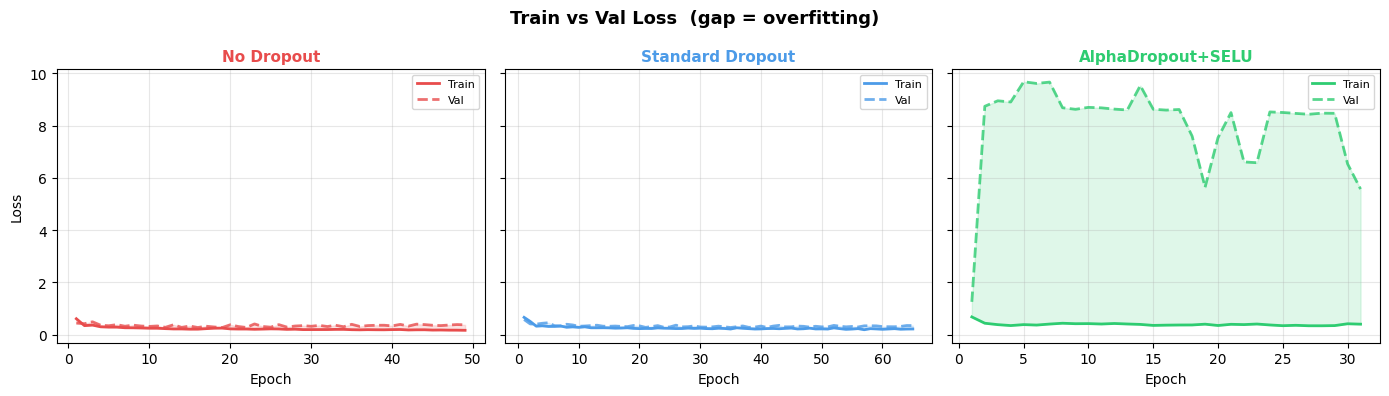

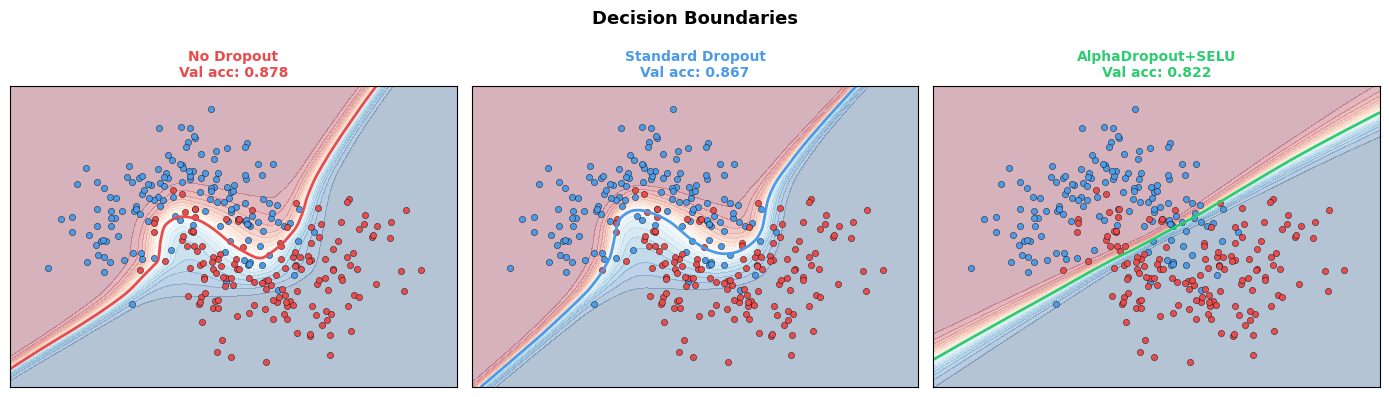

rate=0.0  train=0.910  val=0.922
rate=0.1  train=0.919  val=0.922
rate=0.2  train=0.910  val=0.911
rate=0.3  train=0.914  val=0.878
rate=0.4  train=0.910  val=0.889
rate=0.5  train=0.910  val=0.878
rate=0.6  train=0.910  val=0.878
rate=0.7  train=0.910  val=0.889


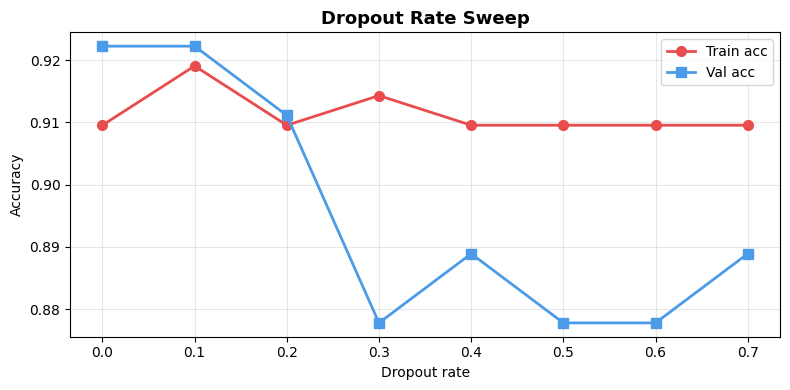

In [17]:
# ─────────────────────────────────────────────
# CELL 5 — Run A/B variants
# ─────────────────────────────────────────────
VARIANTS = [
    (NoDropoutMLP,      'No Dropout',        '#E84C4C'),
    (StandardDropoutMLP,'Standard Dropout',  '#4C9BE8'),
    (AlphaDropoutMLP,   'AlphaDropout+SELU', '#2ECC71'),
]

histories, models_dict = {}, {}

for cls, label, color in VARIANTS:
    print(f"Training: {label} ...", end=' ', flush=True)
    m, h = train_model(cls)
    histories[label]   = h
    models_dict[label] = m
    print(f"best val acc = {max(h['va']):.4f}")

# ─────────────────────────────────────────────
# CELL 6 — Plot A: Loss curves
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
fig.suptitle('Train vs Val Loss  (gap = overfitting)',
             fontsize=13, fontweight='bold')

for ax, (_, label, color) in zip(axes, VARIANTS):
    h  = histories[label]
    ep = range(1, len(h['tl'])+1)
    ax.plot(ep, h['tl'], color=color, lw=2,        label='Train')
    ax.plot(ep, h['vl'], color=color, lw=2, ls='--', label='Val', alpha=0.8)
    ax.fill_between(ep, h['tl'], h['vl'], alpha=0.15, color=color)
    ax.set_title(label, fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel('Epoch'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
axes[0].set_ylabel('Loss')
plt.tight_layout(); plt.show()

# ─────────────────────────────────────────────
# CELL 7 — Plot B: Decision boundaries
# ─────────────────────────────────────────────
@torch.no_grad()
def predict_np(model, X_np):
    model.eval()   # ← dropout OFF during normal inference
    t = torch.tensor(X_np, dtype=torch.float32).to(DEVICE)
    return model(t).cpu().numpy()

def plot_boundary(ax, model, X, y, title, color):
    h = 0.03
    x0,x1 = X[:,0].min()-.5, X[:,0].max()+.5
    y0,y1 = X[:,1].min()-.5, X[:,1].max()+.5
    xx,yy = np.meshgrid(np.arange(x0,x1,h), np.arange(y0,y1,h))
    Z = predict_np(model, np.c_[xx.ravel(),yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx,yy,Z,alpha=0.3,cmap='RdBu',levels=20)
    ax.contour( xx,yy,Z,levels=[0.5],colors=[color],linewidths=2)
    ax.scatter(*X[y==0].T,c='#4C9BE8',s=20,edgecolors='k',lw=0.3)
    ax.scatter(*X[y==1].T,c='#E84C4C',s=20,edgecolors='k',lw=0.3)
    va = ((predict_np(model,X_val)>.5).astype(int)==y_val).mean()
    ax.set_title(f'{title}\nVal acc: {va:.3f}',fontsize=10,fontweight='bold',color=color)
    ax.set_xticks([]); ax.set_yticks([])

X_all = np.vstack([X_tr,X_val]); y_all = np.concatenate([y_tr,y_val])
fig, axes = plt.subplots(1,3,figsize=(14,4))
fig.suptitle('Decision Boundaries',fontsize=13,fontweight='bold')
for ax,(cls,label,color) in zip(axes,VARIANTS):
    plot_boundary(ax, models_dict[label], X_all, y_all, label, color)
plt.tight_layout(); plt.show()

# ─────────────────────────────────────────────
# CELL 8 — Dropout rate sweep
# ─────────────────────────────────────────────
rates = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
sw_tr, sw_va = [], []

for r in rates:
    cls = NoDropoutMLP if r == 0.0 else StandardDropoutMLP
    m, h = train_model(cls, rate=r, epochs=250, patience=20)
    sw_tr.append(max(h['ta'])); sw_va.append(max(h['va']))
    print(f"rate={r:.1f}  train={sw_tr[-1]:.3f}  val={sw_va[-1]:.3f}")

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(rates, sw_tr, 'o-', color='#E84C4C', lw=2, ms=7, label='Train acc')
ax.plot(rates, sw_va, 's-', color='#4C9BE8', lw=2, ms=7, label='Val acc')
ax.set_xlabel('Dropout rate'); ax.set_ylabel('Accuracy')
ax.set_title('Dropout Rate Sweep', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

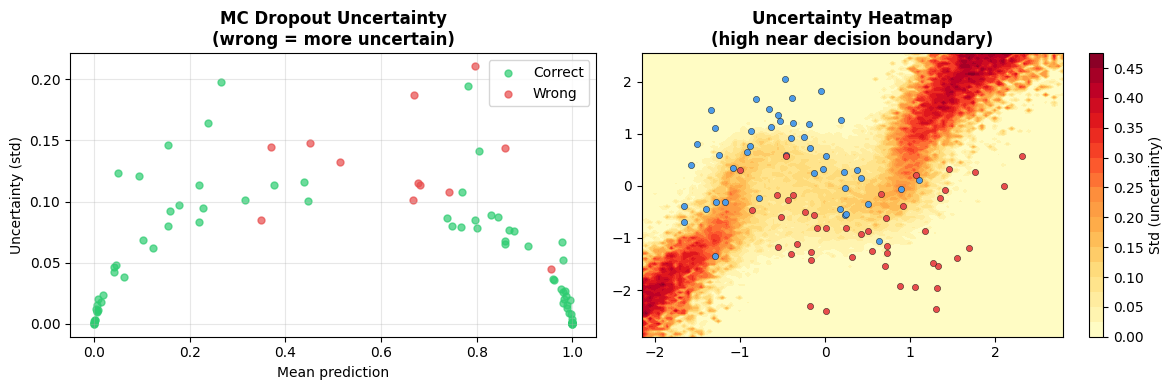


💡 MC Dropout: model.train() at inference = dropout stays ON
   N forward passes → different neurons dropped each time
   std across passes = how unsure the model is
Variant                     Train      Val      Gap
No Dropout                 0.9190   0.9222  -0.0032 ✅
Standard Dropout           0.9143   0.8889   0.0254 ✅
AlphaDropout+SELU          0.8762   0.8556   0.0206 ✅

PYTORCH DROPOUT PATTERNS RECAP
──────────────────────────────────────────────────────────
Standard:     nn.Dropout(p)      — after ReLU in Dense layers
AlphaDropout: nn.AlphaDropout(p) — after SELU; preserves normalization
Spatial:      nn.Dropout2d(p)    — drops entire feature maps; for CNNs
MC Dropout:   model.train() at inference → run N passes → mean±std
 
Critical rule:
  model.train()  → dropout ON  (use during training)
  model.eval()   → dropout OFF (use during normal inference)
  model.train()  → dropout ON  (use again for MC Dropout uncertainty)
 
Inverted dropout (default in PyTorch + Keras):
  Surviv

In [18]:
# ─────────────────────────────────────────────
# CELL 9 — MC Dropout: uncertainty at inference
#
# KEY PyTorch pattern:
#   model.train()   ← switches dropout BACK ON during inference
#   run N forward passes → different masks each time
#   mean = prediction, std = uncertainty
# ─────────────────────────────────────────────
N_PASSES = 50
mc_model = models_dict['Standard Dropout']

def mc_predict_np(model, X_np, n=N_PASSES):
    """Run n stochastic forward passes with dropout active."""
    model.train()   # ← dropout ON during inference (MC trick)
    t = torch.tensor(X_np, dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        preds = torch.stack([model(t) for _ in range(n)])
    model.eval()    # ← restore eval mode after
    return preds.cpu().numpy()   # shape: (n, n_samples)

preds  = mc_predict_np(mc_model, X_val)  # (50, n_val)
mean_p = preds.mean(axis=0)
std_p  = preds.std(axis=0)
correct= (mean_p > 0.5).astype(int) == y_val

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(mean_p[correct],  std_p[correct],
                c='#2ECC71', s=25, alpha=0.7, label='Correct')
axes[0].scatter(mean_p[~correct], std_p[~correct],
                c='#E84C4C', s=25, alpha=0.7, label='Wrong')
axes[0].set_xlabel('Mean prediction'); axes[0].set_ylabel('Uncertainty (std)')
axes[0].set_title('MC Dropout Uncertainty\n(wrong = more uncertain)',
                  fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Uncertainty heatmap
h2 = 0.05
x0,x1 = X_val[:,0].min()-.5, X_val[:,0].max()+.5
y0,y1 = X_val[:,1].min()-.5, X_val[:,1].max()+.5
xx,yy = np.meshgrid(np.arange(x0,x1,h2), np.arange(y0,y1,h2))
gp = mc_predict_np(mc_model, np.c_[xx.ravel(),yy.ravel()], n=20)
gs = gp.std(axis=0).reshape(xx.shape)
im = axes[1].contourf(xx,yy,gs,levels=20,cmap='YlOrRd')
axes[1].scatter(*X_val[y_val==0].T,c='#4C9BE8',s=20,edgecolors='k',lw=0.3)
axes[1].scatter(*X_val[y_val==1].T,c='#E84C4C',s=20,edgecolors='k',lw=0.3)
plt.colorbar(im, ax=axes[1], label='Std (uncertainty)')
axes[1].set_title('Uncertainty Heatmap\n(high near decision boundary)',
                  fontweight='bold')
plt.tight_layout(); plt.show()

print('\n💡 MC Dropout: model.train() at inference = dropout stays ON')
print('   N forward passes → different neurons dropped each time')
print('   std across passes = how unsure the model is')

# ─────────────────────────────────────────────
# CELL 10 — Summary + pattern recap
# ─────────────────────────────────────────────
print('=' * 65)
print(f"{'Variant':<24} {'Train':>8} {'Val':>8} {'Gap':>8}")
print('=' * 65)
for _, label, _ in VARIANTS:
    h  = histories[label]
    tr = max(h['ta']); va = max(h['va']); g = tr - va
    flag = ' ⚠️  OVERFIT' if g > 0.08 else ' ✅'
    print(f'{label:<24} {tr:>8.4f} {va:>8.4f} {g:>8.4f}{flag}')
print('=' * 65)

print("""
PYTORCH DROPOUT PATTERNS RECAP
──────────────────────────────────────────────────────────
Standard:     nn.Dropout(p)      — after ReLU in Dense layers
AlphaDropout: nn.AlphaDropout(p) — after SELU; preserves normalization
Spatial:      nn.Dropout2d(p)    — drops entire feature maps; for CNNs
MC Dropout:   model.train() at inference → run N passes → mean±std

Critical rule:
  model.train()  → dropout ON  (use during training)
  model.eval()   → dropout OFF (use during normal inference)
  model.train()  → dropout ON  (use again for MC Dropout uncertainty)

Inverted dropout (default in PyTorch + Keras):
  Surviving activations scaled by 1/(1-p) during training
  → no scaling needed at test time
  → expected output magnitude is the same in both modes
""")